# **MGMT 59000 - Machine Learning**
## **Learning when to Trust Signals | A Macro-Driven Gating Framework for Regime-Aware Trading**

**Co-authors**: Mishaal Hussain and Syed Bilal Farrukh


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


**Loading Data**

In [2]:
PATH_OLD = "/content/drive/MyDrive/GatingModelData"
PATH_NEW = "/content/drive/MyDrive/GatingModelData2"

import pandas as pd

df_old = pd.read_parquet(PATH_OLD)
df_new = pd.read_parquet(PATH_NEW)

df = pd.concat([df_old, df_new], ignore_index=True)

# Sort properly (VERY IMPORTANT for time series)
df = df.sort_values(["month", "permno"]).reset_index(drop=True)

print(df.shape)
df.head()

(3816941, 181)


,permno,month,ret_excess,mktcap_lag,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,...,sic2_80,sic2_81,sic2_82,sic2_83,sic2_84,sic2_86,sic2_87,sic2_89,sic2_99,year
0,10006,1957-01-01,0.061678,82.249000,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,0,1957
1,10102,1957-01-01,-0.017552,186.193500,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,0,1957
2,10137,1957-01-01,0.006646,225.984000,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,0,1957
3,10145,1957-01-01,-0.060615,962.994375,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,1,1957
4,10153,1957-01-01,-0.035427,279.846875,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,0,1957


## **A) Setup + Sanity Checks**
This section initializes libraries, sets seeds for reproducibility, and ensures all required columns exist in the dataset. It guarantees that the pipeline runs consistently and prevents silent errors later that could invalidate results.

In [3]:
# ## **A) Setup + Sanity Checks**

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ---- Required columns (based on your df preview) ----
ID_COL    = "permno"
MONTH_COL = "month"
RET_COL   = "ret_excess"
CAP_COL   = "mktcap_lag"

req = [ID_COL, MONTH_COL, RET_COL, CAP_COL]
missing = [c for c in req if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.head()

Device: cpu


,permno,month,ret_excess,mktcap_lag,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,...,sic2_80,sic2_81,sic2_82,sic2_83,sic2_84,sic2_86,sic2_87,sic2_89,sic2_99,year
0,10006,1957-01-01,0.061678,82.249000,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,0,1957
1,10102,1957-01-01,-0.017552,186.193500,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,0,1957
2,10137,1957-01-01,0.006646,225.984000,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,0,1957
3,10145,1957-01-01,-0.060615,962.994375,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,1,1957
4,10153,1957-01-01,-0.035427,279.846875,-3.289216,-2.616389,0.544177,0.026149,0.0321,0.0024,...,0,0,0,0,0,0,0,0,0,1957


## **B) Parse Month + Create Next-Month Target (Leakage-Safe)**
The model predicts future returns, so we shift returns forward to create a next-month target (t → t+1) for each stock. This enforces correct time ordering and prevents look-ahead bias, ensuring the model only learns from information available at the decision time.

In [4]:
# ## **B) Parse Month + Create Next-Month Target (Leakage-Safe)**

# Parse month → month-end timestamp (consistent ordering)
df[MONTH_COL] = pd.to_datetime(df[MONTH_COL]).dt.to_period("M").dt.to_timestamp("M")

# Sort strictly
df = df.sort_values([MONTH_COL, ID_COL]).reset_index(drop=True)

# Next-month target for stock i: y_next = ret_excess at t+1
df["y_next"] = df.groupby(ID_COL)[RET_COL].shift(-1)

# Keep realized return at t for market regime labeling
df["ret_t"] = df[RET_COL]

# Drop last month per stock (no next return)
df_model = df.dropna(subset=["y_next", CAP_COL]).copy()

print("df_model shape:", df_model.shape)
df_model[[ID_COL, MONTH_COL, RET_COL, "y_next", CAP_COL]].head()

# ## **FIX: Reset df_model index so month_idx uses positional indices**
df_model = df_model.reset_index(drop=True)
print("df_model reset. New index max:", df_model.index.max(), "| rows:", len(df_model))

df_model shape: (3022443, 183)
df_model reset. New index max: 3022442 | rows: 3022443


## **C) Feature Groups (Macro / Firm / Industry)**
We separate inputs into macro variables, firm characteristics, and industry indicators to reflect different sources of information. This structured grouping allows the model to learn distinct patterns from each data type rather than treating all features as homogeneous.

In [5]:
# ## **C) Feature Groups (Macro / Firm / Industry)**

macro_cols = [c for c in df_model.columns if c.startswith("macro_")]
firm_cols  = [c for c in df_model.columns if c.startswith("characteristic_")]
sic_cols   = [c for c in df_model.columns if c.startswith("sic2_")]

print("macro_cols:", len(macro_cols))
print("firm_cols :", len(firm_cols))
print("sic_cols  :", len(sic_cols))

if len(macro_cols)==0 or len(firm_cols)==0:
    raise ValueError("Could not find macro_* and/or characteristic_* columns. Check prefixes.")

macro_cols: 8
firm_cols : 94
sic_cols  : 74


## **D) Build Fast Month Index (No Repeated Filtering)**
We precompute indices for each month to efficiently retrieve data without repeatedly filtering the full dataset. This significantly speeds up the rolling training process and keeps the pipeline scalable for large datasets.

In [6]:
# ## **D) Build Fast Month Index (positional-safe)**

all_months = np.array(sorted(df_model[MONTH_COL].unique()))
month_to_pos = {m:i for i,m in enumerate(all_months)}

# Use positions (0..n-1), not old labels
month_idx = {}
months_arr = df_model[MONTH_COL].to_numpy()

for m in all_months:
    month_idx[m] = np.where(months_arr == m)[0].astype(np.int64)

print("Months:", len(all_months), "| first:", all_months[0], "| last:", all_months[-1])

Months: 777 | first: 1957-01-31 00:00:00 | last: 2021-11-30 00:00:00


In [7]:
# Sanity: max index must be < len(df_model)
mx = max(v.max() for v in month_idx.values() if len(v)>0)
print("max stored index:", mx, "| len(df_model):", len(df_model))

max stored index: 3022442 | len(df_model): 3022443


## **E) Rolling Window Definition**

10y train, 1y val, test month = t. Retrain every 12 months.

We define a strict time-series validation scheme using 10 years of training data and 1 year of validation before testing on the next month. This mimics real-world deployment and ensures that no future information leaks into the training process.

In [8]:
# ## **E) Rolling Window Definition**

TRAIN_YEARS = 10
VAL_YEARS   = 1
TRAIN_M = TRAIN_YEARS * 12
VAL_M   = VAL_YEARS * 12
RETRAIN_EVERY = 12  # months

def get_window(test_month):
    i = month_to_pos[test_month]
    train_start = i - (TRAIN_M + VAL_M)
    train_end   = i - VAL_M
    val_start   = i - VAL_M
    val_end     = i
    if train_start < 0:
        return None
    train_months = all_months[train_start:train_end]
    val_months   = all_months[val_start:val_end]
    return train_months, val_months, test_month

test_months = []
for m in all_months:
    if get_window(m) is not None:
        test_months.append(m)
test_months = np.array(test_months)

print("Feasible test months:", len(test_months), "| first:", test_months[0], "| last:", test_months[-1])

Feasible test months: 645 | first: 1968-01-31 00:00:00 | last: 2021-11-30 00:00:00


## **F) Preprocessing (Fit on Train Only)**

Missing values are imputed and features are standardized using statistics computed only from the training data. This preserves the integrity of the time-series setup and ensures that transformations do not introduce hidden leakage.

In [9]:
# ## **F) Preprocessing (Fit on Train Only)**

class GroupPreprocessor:
    def __init__(self):
        self.imp = SimpleImputer(strategy="median")
        self.sc  = StandardScaler()

    def fit(self, X):
        Ximp = self.imp.fit_transform(X)
        self.sc.fit(Ximp)
        return self

    def transform(self, X):
        Ximp = self.imp.transform(X)
        return self.sc.transform(Ximp)

## **G) Torch Dataset (Uses Precomputed Arrays)**
We convert structured tabular data into tensors that can be fed into the neural network. Market cap is also used as a weight, allowing the model to prioritize economically important stocks during training.

In [10]:
# ## **G) Torch Dataset**

class PanelDataset(Dataset):
    def __init__(self, Xm, Xf, Xs, y, w):
        self.Xm = Xm.astype(np.float32)
        self.Xf = Xf.astype(np.float32)
        self.Xs = Xs.astype(np.float32)
        self.y  = y.astype(np.float32).reshape(-1,1)
        self.w  = w.astype(np.float32).reshape(-1,1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.Xm[i], self.Xf[i], self.Xs[i], self.y[i], self.w[i]

def make_arrays(idx):
    # idx are row positions in df_model
    sub = df_model.iloc[idx]
    Xm = sub[macro_cols].to_numpy()
    Xf = sub[firm_cols].to_numpy()
    Xs = sub[sic_cols].to_numpy() if len(sic_cols) > 0 else np.zeros((len(sub),0))
    y  = sub["y_next"].to_numpy()
    w  = sub[CAP_COL].to_numpy()
    w  = np.where(np.isfinite(w) & (w>0), w, 0.0)
    # normalize weights for stability
    w  = w / (w.mean() + 1e-8)
    return Xm, Xf, Xs, y, w

## **H) Base Model: Multi-Tower Neural Net**
The model processes macro, firm, and industry features through separate neural “towers” before combining them into a final prediction. This architecture allows the model to learn specialized representations for each data type, improving its ability to capture complex cross-sectional return patterns.

In [11]:
# ## **H) Base Model: Multi-Tower Neural Net**

def mlp(in_dim, hidden=(64,32), dropout=0.0):
    layers = []
    prev = in_dim
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        if dropout > 0:
            layers += [nn.Dropout(dropout)]
        prev = h
    return nn.Sequential(*layers)

class MultiTowerNN(nn.Module):
    def __init__(self, macro_dim, firm_dim, sic_dim,
                 macro_hidden=(32,), firm_hidden=(128,64), sic_hidden=(32,),
                 head_hidden=(64,32), dropout=0.0):
        super().__init__()
        self.has_macro = macro_dim > 0
        self.has_sic   = sic_dim > 0

        self.macro_tower = mlp(macro_dim, macro_hidden, dropout) if self.has_macro else None
        self.firm_tower  = mlp(firm_dim,  firm_hidden,  dropout)
        self.sic_tower   = mlp(sic_dim,   sic_hidden,   dropout) if self.has_sic else None

        out_dim = (macro_hidden[-1] if self.has_macro else 0) + firm_hidden[-1] + (sic_hidden[-1] if self.has_sic else 0)
        self.head = nn.Sequential(mlp(out_dim, head_hidden, dropout), nn.Linear(head_hidden[-1], 1))

    def forward(self, xm, xf, xs):
        reps = []
        if self.macro_tower is not None:
            reps.append(self.macro_tower(xm))
        reps.append(self.firm_tower(xf))
        if self.sic_tower is not None:
            reps.append(self.sic_tower(xs))
        z = torch.cat(reps, dim=1)
        return self.head(z)

def weighted_mse(pred, y, w):
    return torch.mean(w * (pred - y)**2)

## **I) Train + Predict Helpers**
This section defines how the model is trained using weighted loss and how predictions are generated. It ensures that the model learns efficiently while giving more importance to larger firms through market-cap weighting.

In [12]:
# ## **I) Train + Predict Helpers**

def train_model(train_loader, val_loader, macro_dim, firm_dim, sic_dim,
                epochs=5, lr=1e-3):
    model = MultiTowerNN(macro_dim, firm_dim, sic_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float("inf")
    best_state = None

    for ep in range(epochs):
        model.train()
        for xm, xf, xs, y, w in train_loader:
            xm, xf, xs = xm.to(DEVICE), xf.to(DEVICE), xs.to(DEVICE)
            y, w       = y.to(DEVICE), w.to(DEVICE)

            opt.zero_grad()
            pred = model(xm, xf, xs)
            loss = weighted_mse(pred, y, w)
            loss.backward()
            opt.step()

        # val
        model.eval()
        vals = []
        with torch.no_grad():
            for xm, xf, xs, y, w in val_loader:
                xm, xf, xs = xm.to(DEVICE), xf.to(DEVICE), xs.to(DEVICE)
                y, w       = y.to(DEVICE), w.to(DEVICE)
                pred = model(xm, xf, xs)
                vals.append(weighted_mse(pred, y, w).item())
        v = float(np.mean(vals))
        if v < best_val:
            best_val = v
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

@torch.no_grad()
def predict(model, Xm, Xf, Xs):
    model.eval()
    xm = torch.from_numpy(Xm.astype(np.float32)).to(DEVICE)
    xf = torch.from_numpy(Xf.astype(np.float32)).to(DEVICE)
    xs = torch.from_numpy(Xs.astype(np.float32)).to(DEVICE)
    pred = model(xm, xf, xs).detach().cpu().numpy().reshape(-1)
    return pred

## **J) Rolling Walk-Forward Training + Out-of-Sample Predictions**
This produces results_df with stock-level predictions for each test month. The model is repeatedly trained on past data and tested on future months in a rolling manner. This produces truly out-of-sample predictions and simulates how the model would perform in a live trading environment.

In [13]:
# ## **J) Rolling Walk-Forward Training + OOS Predictions**

BATCH_SIZE = 4096
EPOCHS     = 5     # you can raise later (10–20) once it runs
LR         = 1e-3

results = []

current_model = None
current_preps = None
last_retrain_pos = None

for k, t in enumerate(test_months):
    win = get_window(t)
    if win is None:
        continue
    train_months, val_months, test_month = win

    tpos = month_to_pos[t]
    need_retrain = (last_retrain_pos is None) or ((tpos - last_retrain_pos) >= RETRAIN_EVERY)

    # Build indices for train/val/test
    train_idx = np.concatenate([month_idx[m] for m in train_months])
    val_idx   = np.concatenate([month_idx[m] for m in val_months])
    test_idx  = month_idx[test_month]

    if need_retrain:
        # Fit preprocessors on TRAIN only (leakage-safe)
        Xm_tr, Xf_tr, Xs_tr, y_tr, w_tr = make_arrays(train_idx)
        Xm_va, Xf_va, Xs_va, y_va, w_va = make_arrays(val_idx)

        prep_m = GroupPreprocessor().fit(Xm_tr)
        prep_f = GroupPreprocessor().fit(Xf_tr)

        Xm_tr = prep_m.transform(Xm_tr)
        Xm_va = prep_m.transform(Xm_va)
        Xf_tr = prep_f.transform(Xf_tr)
        Xf_va = prep_f.transform(Xf_va)

        train_ds = PanelDataset(Xm_tr, Xf_tr, Xs_tr, y_tr, w_tr)
        val_ds   = PanelDataset(Xm_va, Xf_va, Xs_va, y_va, w_va)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

        current_model = train_model(train_loader, val_loader,
                                    macro_dim=len(macro_cols),
                                    firm_dim=len(firm_cols),
                                    sic_dim=len(sic_cols),
                                    epochs=EPOCHS, lr=LR)
        current_preps = (prep_m, prep_f)
        last_retrain_pos = tpos

    # Predict on TEST month using TRAIN-fitted preprocessors
    Xm_te, Xf_te, Xs_te, y_te, w_te = make_arrays(test_idx)
    Xm_te = current_preps[0].transform(Xm_te)
    Xf_te = current_preps[1].transform(Xf_te)

    pred = predict(current_model, Xm_te, Xf_te, Xs_te)

    sub = df_model.iloc[test_idx][[MONTH_COL, ID_COL, CAP_COL]].copy()
    sub["pred"] = pred
    sub["ret_next"] = df_model.iloc[test_idx]["y_next"].values  # realized next-month return

    results.append(sub)

    if (k+1) % 24 == 0:
        print(f"Processed {k+1}/{len(test_months)} test months")

results_df = pd.concat(results, ignore_index=True)
print("results_df:", results_df.shape)
results_df.head()

Processed 24/645 test months
Processed 48/645 test months
Processed 72/645 test months
Processed 96/645 test months
Processed 120/645 test months
Processed 144/645 test months
Processed 168/645 test months
Processed 192/645 test months
Processed 216/645 test months
Processed 240/645 test months
Processed 264/645 test months
Processed 288/645 test months
Processed 312/645 test months
Processed 336/645 test months
Processed 360/645 test months
Processed 384/645 test months
Processed 408/645 test months
Processed 432/645 test months
Processed 456/645 test months
Processed 480/645 test months
Processed 504/645 test months
Processed 528/645 test months
Processed 552/645 test months
Processed 576/645 test months
Processed 600/645 test months
Processed 624/645 test months
results_df: (2899870, 5)


,month,permno,mktcap_lag,pred,ret_next
0,1968-01-31,10006,253.229625,0.019908,-0.041053
1,1968-01-31,10014,35.340000,0.032069,-0.084360
2,1968-01-31,10030,106.346250,0.008427,0.000302
3,1968-01-31,10057,44.239500,0.009524,-0.049614
4,1968-01-31,10102,384.025875,0.011924,-0.052809


#### **Baseline Model Cumulative Returns**

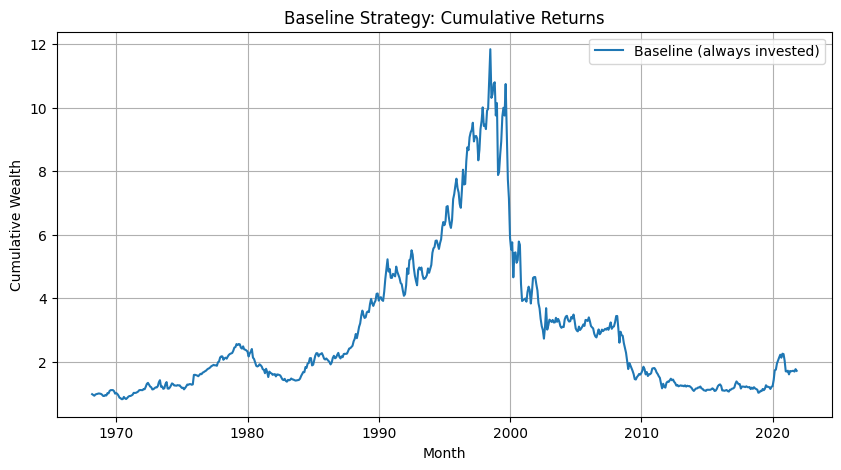

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Baseline returns (always invested) ---
baseline = meta.copy().sort_values("month").reset_index(drop=True)

# cumulative wealth
baseline["cum_wealth"] = (1 + baseline["R_LS_next"]).cumprod()

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(baseline["month"], baseline["cum_wealth"], label="Baseline (always invested)")

plt.title("Baseline Strategy: Cumulative Returns")
plt.xlabel("Month")
plt.ylabel("Cumulative Wealth")
plt.legend()

# Optional: highlight breakdown period (manually adjust if needed)
# Example:
# plt.axvspan(350, 420, alpha=0.2)

plt.grid(True)
plt.show()

## **K) Baseline Strategy: Value-Weighted Decile Long–Short**
Predictions are converted into a trading strategy by going long the highest predicted stocks and short the lowest. This translates model outputs into economic value, allowing performance to be evaluated in terms of returns rather than prediction error.

In [14]:
# ## **K) Baseline Strategy: Value-Weighted Decile Long–Short**

DECILES = 10

def vw_return(g, ret_col="ret_next"):
    w = g[CAP_COL].to_numpy(dtype=float)
    r = g[ret_col].to_numpy(dtype=float)
    w = np.where(np.isfinite(w) & (w>0), w, 0.0)
    if w.sum() == 0:
        return np.nan
    w = w / w.sum()
    return float(np.sum(w * r))

strategy_rows = []
for m, g in results_df.groupby(MONTH_COL):
    g = g.dropna(subset=["pred", "ret_next", CAP_COL]).copy()
    if len(g) < DECILES:
        continue

    # Deciles by predicted return
    g["decile"] = pd.qcut(g["pred"].rank(method="first"), q=DECILES, labels=False) + 1

    long_leg  = g[g["decile"] == DECILES]
    short_leg = g[g["decile"] == 1]

    r_long  = vw_return(long_leg,  "ret_next")
    r_short = vw_return(short_leg, "ret_next")
    r_ls = r_long - r_short

    strategy_rows.append({"month": m, "R_long": r_long, "R_short": r_short, "R_LS": r_ls})

strategy_df = pd.DataFrame(strategy_rows).sort_values("month").reset_index(drop=True)
strategy_df.head()

,month,R_long,R_short,R_LS
0,1968-01-31,-0.047853,-0.054025,0.006172
1,1968-02-29,0.001521,-0.005789,0.007311
2,1968-03-31,0.108516,0.125832,-0.017315
3,1968-04-30,0.041834,0.069018,-0.027184
4,1968-05-31,-0.004390,0.018871,-0.023261


## **L) Market Return + Bull/Bear Regime Labels**
We compute overall market returns and classify each month as bull or bear based on market direction. This enables analysis of how the strategy behaves under different market conditions.

In [15]:
# ## **L) Market Return + Regime Labels (Bull/Bear + Volatility)**

# Value-weighted market excess return using lagged market cap weights
mkt = (df_model.dropna(subset=["ret_t", CAP_COL])
       .groupby(MONTH_COL)
       .apply(lambda g: np.sum((g[CAP_COL] / g[CAP_COL].sum()) * g["ret_t"]))
       .rename("R_mkt")
       .reset_index()
       .rename(columns={MONTH_COL: "month"})
       .sort_values("month")
       .reset_index(drop=True))

# Bull/Bear regime
mkt["regime"] = np.where(mkt["R_mkt"] > 0, "bull", "bear")

# Volatility regime (12m rolling realized vol)
mkt["vol12"] = mkt["R_mkt"].rolling(12, min_periods=12).std()
vol_cut = mkt["vol12"].median(skipna=True)
mkt["vol_regime"] = np.where(mkt["vol12"] >= vol_cut, "high_vol", "low_vol")

# Keep ONE canonical market dataframe for the rest of the notebook
market_df = mkt[["month", "R_mkt", "regime", "vol_regime"]].copy()

market_df.head()

/tmp/ipython-input-2046991317.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.sum((g[CAP_COL] / g[CAP_COL].sum()) * g["ret_t"]))


,month,R_mkt,regime,vol_regime
0,1957-01-31,-0.040262,bear,low_vol
1,1957-02-28,-0.019019,bear,low_vol
2,1957-03-31,0.020987,bull,low_vol
3,1957-04-30,0.045317,bull,low_vol
4,1957-05-31,0.035991,bull,low_vol


## **M) Meta Dataset (Month-Level “Risk Manager”)**

Label: 1(R_LS_{t+1} > 0)
Inputs: macro state + prediction diagnostics + lagged strategy return.

We construct a second dataset at the monthly level using macro variables and diagnostics of the model’s predictions. This shifts the focus from predicting returns to predicting whether the strategy itself will perform well.

In [16]:
# ## **M) Meta Dataset (Month-Level Risk Manager)**

from scipy.stats import spearmanr

# --- 1) Month-level diagnostics from NN predictions at month t ---
# Uses results_df columns: MONTH_COL, pred, y_true (or y_next), CAP_COL optional
diag_rows = []

for m, g in results_df.groupby(MONTH_COL):
    # keep only rows with valid predictions + realized returns for IC/spread
    g = g.copy()
    g = g[np.isfinite(g["pred"].to_numpy(dtype=float))]

    if len(g) == 0:
        continue

    p = g["pred"].to_numpy(dtype=float)

    # basic distribution diagnostics (available at time t)
    pred_mean = float(np.mean(p))
    pred_std  = float(np.std(p))
    pred_skew = float(pd.Series(p).skew())
    spread_90_10 = float(np.nanquantile(p, 0.9) - np.nanquantile(p, 0.1))

    # IC (rank corr between predictions and realized next-month returns)
    # Use y_true if you already store next-month return there; otherwise fallback to y_next.
    y_col = "y_true" if "y_true" in g.columns else ("y_next" if "y_next" in g.columns else None)
    ic = np.nan
    dec_spread = np.nan

    if y_col is not None:
        g2 = g.dropna(subset=[y_col]).copy()

        if len(g2) >= 10:
            y = g2[y_col].to_numpy(dtype=float)
            p2 = g2["pred"].to_numpy(dtype=float)

            # Spearman IC
            try:
                ic_val = spearmanr(p2, y, nan_policy="omit").correlation
                ic = float(ic_val) if ic_val is not None else np.nan
            except Exception:
                ic = np.nan

            # Realized top-minus-bottom decile spread (simple equal-weight)
            rk = g2["pred"].rank(method="first", pct=True)
            top = g2.loc[rk >= 0.9, y_col].mean()
            bot = g2.loc[rk <= 0.1, y_col].mean()
            dec_spread = float(top - bot)

    diag_rows.append({
        "month": m,
        "pred_mean": pred_mean,
        "pred_std": pred_std,
        "pred_skew": pred_skew,
        "pred_top_bot_spread": spread_90_10,
        "ic_spearman": ic,
        "decile_spread": dec_spread,
    })

diag_df = pd.DataFrame(diag_rows).sort_values("month").reset_index(drop=True)

# --- 2) Macro at month t (same across firms => one row per month) ---
macro_month = (
    df_model[[MONTH_COL] + macro_cols]
    .drop_duplicates(subset=[MONTH_COL])
    .rename(columns={MONTH_COL: "month"})
    .sort_values("month")
)

# --- 3) Strategy series (your existing monthly long-short return series) ---
strat = strategy_df.rename(columns={"month": "month"}).copy()

# --- 4) Merge meta table ---
meta = (
    macro_month
    .merge(diag_df, on="month", how="inner")
    .merge(strat[["month", "R_LS"]], on="month", how="inner")
    .merge(market_df, on="month", how="left")   # expects market_df has month + regime columns
    .sort_values("month")
    .reset_index(drop=True)
)

# --- 5) Label = NEXT month success (trade decision made at month t for month t+1) ---
meta["R_LS_next"]  = meta["R_LS"].shift(-1)
meta["meta_label"] = (meta["R_LS_next"] > 0).astype(int)

# --- 6) Lagged performance feature available at end of month t ---
# IMPORTANT: lag it by 1 to avoid leaking current month into itself
meta["R_LS_lag1"] = meta["R_LS"].shift(1)

# Drop rows that can't be used
meta = meta.dropna(subset=["R_LS_next", "R_LS_lag1"]).reset_index(drop=True)

print("meta shape:", meta.shape)
meta.head()

meta shape: (642, 22)


,month,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,macro_dfy,macro_svar,pred_mean,...,pred_top_bot_spread,ic_spearman,decile_spread,R_LS,R_mkt,regime,vol_regime,R_LS_next,meta_label,R_LS_lag1
0,1968-02-29,-3.449391,-2.844181,0.556302,0.012854,0.0500,0.0036,0.0067,0.000483,0.017244,...,0.030833,NaN,NaN,0.007311,-0.036958,bear,low_vol,-0.017315,0,0.006172
1,1968-03-31,-3.414264,-2.805663,0.566211,0.010451,0.0498,0.0044,0.0070,0.000820,0.020572,...,0.030766,NaN,NaN,-0.017315,0.002539,bull,low_vol,-0.027184,0,0.007311
2,1968-04-30,-3.420224,-2.808250,0.566810,0.012677,0.0517,0.0043,0.0074,0.001395,0.018969,...,0.031209,NaN,NaN,-0.027184,0.088563,bull,high_vol,-0.023261,0,-0.017315
3,1968-05-31,-3.494472,-2.879068,0.522352,0.008140,0.0538,0.0009,0.0076,0.001608,0.020774,...,0.034694,NaN,NaN,-0.023261,0.020121,bull,low_vol,0.041577,1,-0.027184
4,1968-06-30,-3.501067,-2.882291,0.530033,0.010647,0.0566,-0.0019,0.0076,0.000387,0.033010,...,0.035543,NaN,NaN,0.041577,0.006095,bull,low_vol,0.012490,1,-0.023261


## **N) Train Meta-Model (Logistic Regression) — Chronological Split**

#### **N1) Fixed Meta-Model | Logistic Regression — Baseline for Gating**

We fit three versions: macro-only, diagnostics-only, both.

A simple logistic regression model predicts the probability that the strategy will succeed in the next month. Its simplicity improves interpretability and reduces overfitting, making it a reliable decision layer.

In [17]:
# ## **N) Train Meta-Model (Logistic Regression — Fixed Chronological Split)**

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

META_TRAIN_FRAC = 0.70  # fixed time split (early train, late test)

# Features (must exist in meta from Part M)
macro_use = macro_cols.copy()
diag_cols = [
    "pred_mean", "pred_std", "pred_skew", "pred_top_bot_spread",
    "ic_spearman", "decile_spread",
    "R_LS_lag1"
]

def time_split(df, frac=META_TRAIN_FRAC):
    """Chronological split (no shuffling)."""
    df = df.sort_values("month").reset_index(drop=True)
    cut = int(np.floor(len(df) * frac))
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()

def fit_logit_fixed(meta_df, feature_cols):
    """
    Fit one LR model on early months and apply it to all months.
    Returns train/test AUC (for overfit discussion) + p_t for gating.
    """
    meta_df = meta_df.sort_values("month").reset_index(drop=True).copy()
    tr, te = time_split(meta_df)

    # X/y
    X_tr = tr[feature_cols].to_numpy(float)
    y_tr = tr["meta_label"].to_numpy(int)
    X_te = te[feature_cols].to_numpy(float)
    y_te = te["meta_label"].to_numpy(int)

    # preprocess (fit on train only)
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr = sc.fit_transform(imp.fit_transform(X_tr))
    X_te = sc.transform(imp.transform(X_te))

    # model
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_tr, y_tr)

    # AUC for discussion
    p_tr = clf.predict_proba(X_tr)[:, 1]
    p_te = clf.predict_proba(X_te)[:, 1]
    auc_tr = roc_auc_score(y_tr, p_tr) if len(np.unique(y_tr)) > 1 else np.nan
    auc_te = roc_auc_score(y_te, p_te) if len(np.unique(y_te)) > 1 else np.nan

    # probabilities for all months (gating uses p_t at month t)
    X_all = sc.transform(imp.transform(meta_df[feature_cols].to_numpy(float)))
    p_all = clf.predict_proba(X_all)[:, 1]

    p_df = meta_df[["month"]].copy()
    p_df["p_t"] = p_all

    return {"p_df": p_df, "auc_tr": auc_tr, "auc_te": auc_te}

# Fit fixed-split meta models
meta_models = {
    "macro_only": fit_logit_fixed(meta, macro_use),
    "diag_only":  fit_logit_fixed(meta, diag_cols),
    "both":       fit_logit_fixed(meta, macro_use + diag_cols),
}

for k, v in meta_models.items():
    print(k, "| AUC train:", round(v["auc_tr"], 4), "AUC test:", round(v["auc_te"], 4))

macro_only | AUC train: 0.6029 AUC test: 0.4928
diag_only | AUC train: 0.6175 AUC test: 0.4413
both | AUC train: 0.6318 AUC test: 0.4468


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [4 5]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [4 5]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [4 5]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [12 13]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:63

#### **N2) Rolling Meta-Model for Regime Adaptation (Expanding Window)**

In [18]:
# ## **N2) Meta-Model (Logistic Regression — Rolling / Expanding Window)**

def fit_logit_rolling(meta_df, feature_cols, min_train=60):
    """
    Expanding window:
    For each month index i, fit on months [0..i-1], predict p_t for month i.
    More realistic for non-stationarity; slower (but LR is still fast).
    """
    df = meta_df.sort_values("month").reset_index(drop=True).copy()

    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()
    clf = LogisticRegression(max_iter=2000)

    p = np.full(len(df), np.nan)

    for i in range(min_train, len(df)):
        tr = df.iloc[:i]
        te = df.iloc[i:i+1]

        X_tr = sc.fit_transform(imp.fit_transform(tr[feature_cols].to_numpy(float)))
        y_tr = tr["meta_label"].to_numpy(int)
        clf.fit(X_tr, y_tr)

        X_te = sc.transform(imp.transform(te[feature_cols].to_numpy(float)))
        p[i] = clf.predict_proba(X_te)[:, 1][0]

    p_df = df[["month"]].copy()
    p_df["p_t"] = p
    return {"p_df": p_df, "min_train": min_train}

# Fit rolling meta models (same feature sets)
meta_models_roll = {
    "macro_only_roll": fit_logit_rolling(meta, macro_use, min_train=60),
    "diag_only_roll":  fit_logit_rolling(meta, diag_cols, min_train=60),
    "both_roll":       fit_logit_rolling(meta, macro_use + diag_cols, min_train=60),
}

print("Rolling predictions available (non-NaN months):")
for k, v in meta_models_roll.items():
    print(k, ":", int(v["p_df"]["p_t"].notna().sum()), "/", len(v["p_df"]))

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [4 5]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [4 5]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [4 5]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [4 5]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635:

Rolling predictions available (non-NaN months):
macro_only_roll : 582 / 642
diag_only_roll : 582 / 642
both_roll : 582 / 642


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [12 13]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [12 13]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [12 13]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [12 13]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base

#### **N3) Fixed vs Rolling Gating Comparison (Performance Evaluation)**

In [19]:
# --- Define fixed vs rolling for comparison ---
p_fixed = meta_models["both"]["p_df"][["month", "p_t"]].rename(columns={"p_t": "p_gate"})
p_roll  = meta_models_roll["both_roll"]["p_df"][["month", "p_t"]].rename(columns={"p_t": "p_gate"})

In [23]:
import math

def perf_stats(r):
    r = pd.Series(r).dropna()
    ann_ret = 12 * r.mean()
    ann_vol = math.sqrt(12) * r.std(ddof=1)
    sharpe  = ann_ret / (ann_vol + 1e-12)
    wealth  = (1 + r).cumprod()
    dd      = wealth / wealth.cummax() - 1
    return {
        "AnnRet": float(ann_ret),
        "AnnVol": float(ann_vol),
        "Sharpe": float(sharpe),
        "MaxDD":  float(dd.min()),
    }

def run_gating(meta_df, p_df, tau=0.55, soft=False):
    df = meta_df.merge(p_df, on="month", how="left").sort_values("month").reset_index(drop=True)

    p = df["p_gate"].to_numpy(float)
    if soft:
        exp = np.clip((p - tau) / (1 - tau + 1e-12), 0, 1)
    else:
        exp = (p >= tau).astype(float)

    out = df[["month", "regime", "vol_regime", "R_LS_next"]].copy()
    out["exposure"] = exp
    out["R_gated"]  = exp * out["R_LS_next"].to_numpy(float)
    return out

TAUS = [0.50, 0.55, 0.60]

rows = []
for tau in TAUS:
    for name, p_df in [("fixed", p_fixed), ("rolling", p_roll)]:
        for soft in [False, True]:
            tag = f"{name}_{'soft' if soft else 'binary'}"
            out = run_gating(meta, p_df, tau=tau, soft=soft)

            s_all  = perf_stats(out["R_gated"])
            s_bull = perf_stats(out.loc[out["regime"]=="bull", "R_gated"])
            s_bear = perf_stats(out.loc[out["regime"]=="bear", "R_gated"])

            rows.append({
                "model": tag, "tau": tau,
                "TradeRate": float((out["exposure"] > 0).mean()),
                "AvgExp": float(out["exposure"].mean()),
                "Sharpe": s_all["Sharpe"], "MaxDD": s_all["MaxDD"],
                "BullSharpe": s_bull["Sharpe"], "BearSharpe": s_bear["Sharpe"],
            })

summary = pd.DataFrame(rows).sort_values(["Sharpe"], ascending=False)
summary.head(72)

,model,tau,TradeRate,AvgExp,Sharpe,MaxDD,BullSharpe,BearSharpe
0,fixed_binary,0.50,0.702492,0.702492,0.295469,-0.772673,0.214740,0.432029
1,fixed_soft,0.50,0.702492,0.160383,0.215986,-0.384637,0.260246,0.151552
4,fixed_binary,0.55,0.503115,0.503115,0.215021,-0.771626,0.106506,0.418048
8,fixed_binary,0.60,0.347352,0.347352,0.207225,-0.572967,0.178635,0.249578
5,fixed_soft,0.55,0.503115,0.111108,0.178879,-0.374209,0.261835,0.062117
9,fixed_soft,0.60,0.347352,0.073637,0.152059,-0.360235,0.274129,-0.018281
2,rolling_binary,0.50,0.595016,0.595016,0.120289,-0.829416,0.138336,0.094181
3,rolling_soft,0.50,0.595016,0.201795,0.087723,-0.456128,0.135435,0.009763
11,rolling_soft,0.60,0.364486,0.119703,0.078778,-0.316844,0.145210,-0.027742
7,rolling_soft,0.55,0.468847,0.157947,0.073773,-0.400511,0.123195,-0.006863


#### **N4) Gate Probability Dynamics: Fixed vs Rolling**

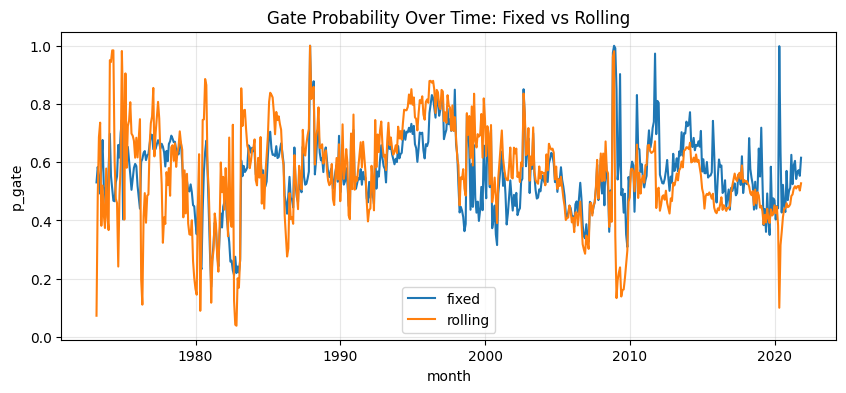

In [24]:
# Compare p_gate behavior (Fixed vs Rolling) — clean + correct order
tmp = (meta[["month"]]
       .merge(p_fixed.rename(columns={"p_gate": "p_fixed"}), on="month", how="left")
       .merge(p_roll.rename(columns={"p_gate": "p_roll"}),  on="month", how="left"))

tmp = tmp.sort_values("month").reset_index(drop=True)

# Drop early rolling months (NaN until min_train)
tmp = tmp.dropna(subset=["p_roll"]).reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.plot(tmp["month"], tmp["p_fixed"], label="fixed")
plt.plot(tmp["month"], tmp["p_roll"], label="rolling")
plt.title("Gate Probability Over Time: Fixed vs Rolling")
plt.xlabel("month")
plt.ylabel("p_gate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

##### **Fixed vs Rolling Meta-Model: Trade-offs and Limitations**

A rolling (expanding window) meta-model is theoretically more appropriate in a non-stationary environment such as financial markets, as it allows the model to continuously adapt to evolving relationships between features and returns. However, this comes at the cost of increased estimation noise and computational complexity.

In our empirical results, the rolling meta-model produces significantly more volatile and unstable gate probabilities compared to the fixed model, as seen in the probability dynamics. This suggests that the model is overfitting to short-term fluctuations in the data rather than learning persistent regime patterns. The limited amount of recent data available at each step further exacerbates this issue, leading to high variance and unreliable predictions.

In contrast, the fixed meta-model, trained on a larger historical sample, generates smoother and more stable probability estimates. While it does not explicitly adapt to regime shifts, it captures more generalizable patterns and avoids reacting to short-term noise, resulting in better risk-adjusted performance.

A key limitation of the fixed approach is that it may fail to fully adjust to structural changes in the market. Future work could explore hybrid approaches, such as regularized rolling models or regime-switching frameworks, that balance adaptability with stability.

## **O) Gating + Metrics**
The meta-model controls exposure by deciding when to trade based on predicted probabilities. This acts as a risk management layer, aiming to reduce losses in unfavorable conditions while preserving gains.

In [38]:
# ## **O) Gating + Metrics (Binary & Soft, Threshold Sweep, Ablations)**

TAUS = [0.50, 0.52, 0.55, 0.58, 0.60, 0.65]

# combine fixed + rolling meta-models (assumes you ran N + N2)
meta_models_all = {**meta_models, **meta_models_roll}

def ann_metrics(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return {"AnnRet": np.nan, "AnnVol": np.nan, "Sharpe": np.nan, "MaxDD": np.nan}

    ann_ret = 12 * r.mean()
    ann_vol = math.sqrt(12) * r.std(ddof=1)
    sharpe  = ann_ret / (ann_vol + 1e-12)

    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1

    return {"AnnRet": float(ann_ret), "AnnVol": float(ann_vol), "Sharpe": float(sharpe), "MaxDD": float(dd.min())}

def apply_gating(meta_df, p_df, tau, soft=False):
    tmp = meta_df.merge(p_df, on="month", how="left").sort_values("month").reset_index(drop=True)

    # Gate next month return: R_LS_next is R_{t+1}
    p = tmp["p_t"].to_numpy(float)
    p = np.nan_to_num(p, nan=-1.0)  # rolling has NaNs early -> treat as "never trade"

    if soft:
        exposure = np.clip((p - tau) / (1 - tau + 1e-12), 0, 1)
    else:
        exposure = (p >= tau).astype(float)

    out = pd.DataFrame({
        "month": tmp["month"].values,
        "regime": tmp["regime"].values,
        "vol_regime": tmp["vol_regime"].values,
        "p_t": p,
        "exposure": exposure,
        "R_base": tmp["R_LS_next"].values,
        "R_gated": exposure * tmp["R_LS_next"].values
    })
    return out

def summarize_variant(df_variant, name, tau):
    m_all  = ann_metrics(df_variant["R_gated"])
    tr     = float(np.mean(df_variant["exposure"] > 0))
    avgexp = float(np.mean(df_variant["exposure"]))

    # bull/bear split
    m_bull = ann_metrics(df_variant.loc[df_variant["regime"] == "bull", "R_gated"])
    m_bear = ann_metrics(df_variant.loc[df_variant["regime"] == "bear", "R_gated"])

    return {
        "name": name, "tau": tau,
        "TradeRate": tr, "AvgExposure": avgexp,
        **{f"ALL_{k}": v for k, v in m_all.items()},
        **{f"BULL_{k}": v for k, v in m_bull.items()},
        **{f"BEAR_{k}": v for k, v in m_bear.items()},
    }

# Baseline: always trade
baseline = pd.DataFrame({
    "month": meta["month"].values,
    "regime": meta["regime"].values,
    "vol_regime": meta["vol_regime"].values,
    "exposure": 1.0,
    "R_base": meta["R_LS_next"].values,
    "R_gated": meta["R_LS_next"].values
})

summary_rows = [summarize_variant(baseline, "baseline_always", tau=np.nan)]
variants_store = {}

for model_name, mm in meta_models_all.items():
    for tau in TAUS:
        vb = apply_gating(meta, mm["p_df"], tau=tau, soft=False)
        vs = apply_gating(meta, mm["p_df"], tau=tau, soft=True)

        key_b = f"{model_name}_binary_tau_{tau:.2f}"
        key_s = f"{model_name}_soft_tau_{tau:.2f}"

        variants_store[key_b] = vb
        variants_store[key_s] = vs

        summary_rows.append(summarize_variant(vb, key_b, tau))
        summary_rows.append(summarize_variant(vs, key_s, tau))

metrics_table = pd.DataFrame(summary_rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

metrics_table.sort_values("ALL_Sharpe", ascending=False)


,name,tau,TradeRate,AvgExposure,ALL_AnnRet,ALL_AnnVol,ALL_Sharpe,ALL_MaxDD,BULL_AnnRet,BULL_AnnVol,BULL_Sharpe,BULL_MaxDD,BEAR_AnnRet,BEAR_AnnVol,BEAR_Sharpe,BEAR_MaxDD
7,macro_only_binary_tau_0.58,0.58,0.411215,0.411215,0.036959,0.109370,0.337928,-0.681687,0.030034,0.110189,0.272566,-0.600069,0.047200,0.108291,0.435862,-0.361573
17,diag_only_binary_tau_0.55,0.55,0.520249,0.520249,0.039918,0.125685,0.317601,-0.686372,0.032699,0.131632,0.248417,-0.702891,0.050592,0.116518,0.434198,-0.278916
5,macro_only_binary_tau_0.55,0.55,0.484424,0.484424,0.034316,0.115909,0.296057,-0.678584,0.028641,0.116564,0.245714,-0.597911,0.042706,0.115115,0.370989,-0.383426
25,both_binary_tau_0.50,0.50,0.702492,0.702492,0.043410,0.146919,0.295469,-0.772673,0.033087,0.154079,0.214740,-0.730465,0.058675,0.135813,0.432029,-0.342764
3,macro_only_binary_tau_0.52,0.52,0.609034,0.609034,0.036931,0.131500,0.280847,-0.661190,0.016115,0.134592,0.119734,-0.665153,0.067714,0.126523,0.535187,-0.370477
9,macro_only_binary_tau_0.60,0.60,0.353583,0.353583,0.028094,0.100904,0.278419,-0.660591,0.027994,0.102626,0.272780,-0.600076,0.028240,0.098499,0.286706,-0.361573
27,both_binary_tau_0.52,0.52,0.627726,0.627726,0.037660,0.137250,0.274387,-0.778273,0.027128,0.145551,0.186381,-0.755908,0.053234,0.124101,0.428956,-0.318162
15,diag_only_binary_tau_0.52,0.52,0.732087,0.732087,0.041325,0.153317,0.269540,-0.748593,0.043748,0.147550,0.296494,-0.648983,0.037742,0.161754,0.233332,-0.530503
35,both_binary_tau_0.65,0.65,0.207165,0.207165,0.019150,0.082767,0.231368,-0.502177,0.028201,0.077151,0.365534,-0.345084,0.005764,0.090452,0.063728,-0.333550
13,diag_only_binary_tau_0.50,0.50,0.816199,0.816199,0.036448,0.160928,0.226486,-0.835705,0.033295,0.154461,0.215553,-0.738206,0.041111,0.170339,0.241350,-0.587189


In [39]:
# Confirming which model variants are to be considered for analysis
print(sorted(metrics_table["name"].unique())[:10])

['baseline_always', 'both_binary_tau_0.50', 'both_binary_tau_0.52', 'both_binary_tau_0.55', 'both_binary_tau_0.58', 'both_binary_tau_0.60', 'both_binary_tau_0.65', 'both_roll_binary_tau_0.50', 'both_roll_binary_tau_0.52', 'both_roll_binary_tau_0.55']


#### **Binary vs Soft plots**

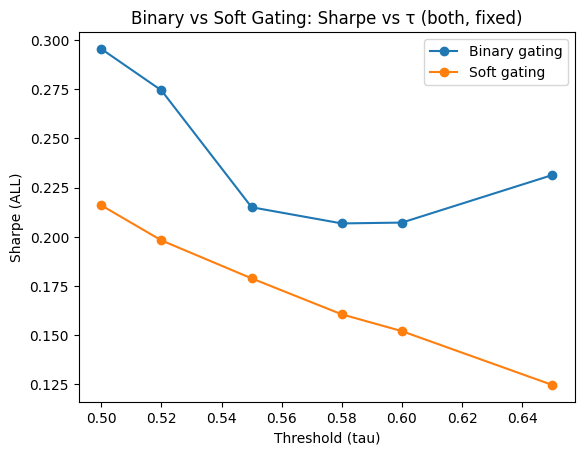

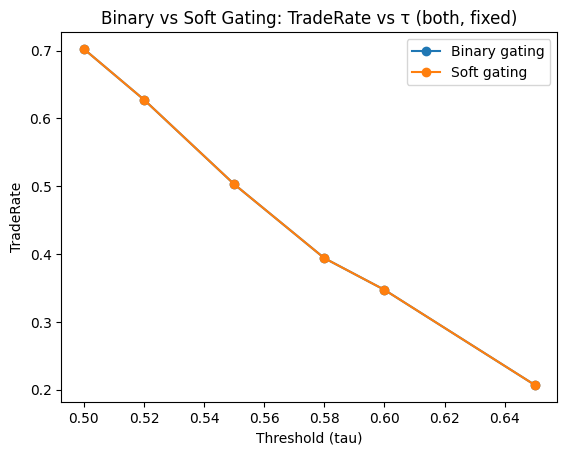

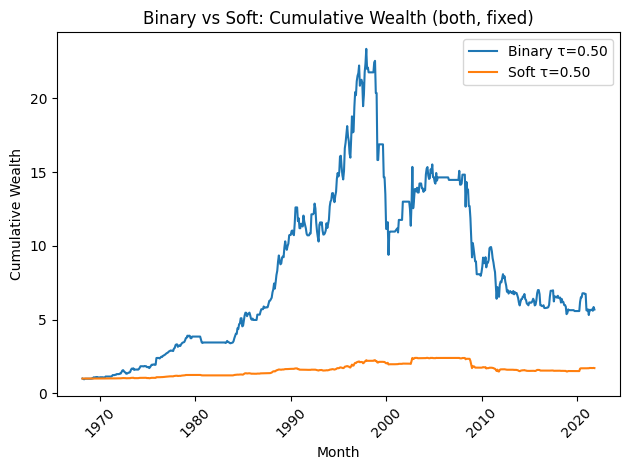

,name,tau,ALL_Sharpe,ALL_AnnRet,ALL_AnnVol,ALL_MaxDD,TradeRate,AvgExposure
25,both_binary_tau_0.50,0.5,0.295469,0.043410,0.146919,-0.772673,0.702492,0.702492
26,both_soft_tau_0.50,0.5,0.215986,0.011424,0.052894,-0.384637,0.702492,0.160383


In [40]:
# === Binary vs Soft Gating Plots (for a fixed feature spec & scheme) ===
# Assumes you have already run Section O so that:
# - variants_store dict exists (keys like "both_binary_tau_0.50", "both_soft_tau_0.50", etc.)
# - metrics_table DataFrame exists
# - TAUS list exists

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- USER SETTINGS (edit these two) ----
FEATURE_SPEC = "both"      # "macro_only", "diag_only", or "both"
SCHEME = "fixed"           # "fixed" or "roll"  (your naming uses *_roll_* for rolling)
TAU_SHOW = 0.50            # pick one tau to show cumulative wealth comparison

# ---- Build prefixes for keys in variants_store / metrics_table ----
if SCHEME == "fixed":
    prefix_bin = f"{FEATURE_SPEC}_binary_tau_"
    prefix_soft = f"{FEATURE_SPEC}_soft_tau_"
else:
    prefix_bin = f"{FEATURE_SPEC}_roll_binary_tau_"
    prefix_soft = f"{FEATURE_SPEC}_roll_soft_tau_"

def _extract_series(metric_col: str, gate: str):
    """Return x=taus, y=metric values for the chosen spec/scheme and gate type."""
    if gate == "binary":
        mask = metrics_table["name"].str.startswith(prefix_bin)
    else:
        mask = metrics_table["name"].str.startswith(prefix_soft)

    df = metrics_table.loc[mask, ["name", "tau", metric_col]].copy()
    df = df.dropna(subset=["tau"]).sort_values("tau")
    return df["tau"].to_numpy(), df[metric_col].to_numpy()

# ---- 1) Sharpe vs tau ----
taus_b, sharpe_b = _extract_series("ALL_Sharpe", "binary")
taus_s, sharpe_s = _extract_series("ALL_Sharpe", "soft")

plt.figure()
plt.plot(taus_b, sharpe_b, marker="o", label="Binary gating")
plt.plot(taus_s, sharpe_s, marker="o", label="Soft gating")
plt.xlabel("Threshold (tau)")
plt.ylabel("Sharpe (ALL)")
plt.title(f"Binary vs Soft Gating: Sharpe vs τ ({FEATURE_SPEC}, {SCHEME})")
plt.legend()
plt.show()

# ---- 2) TradeRate vs tau ----
taus_b, tr_b = _extract_series("TradeRate", "binary")
taus_s, tr_s = _extract_series("TradeRate", "soft")

plt.figure()
plt.plot(taus_b, tr_b, marker="o", label="Binary gating")
plt.plot(taus_s, tr_s, marker="o", label="Soft gating")
plt.xlabel("Threshold (tau)")
plt.ylabel("TradeRate")
plt.title(f"Binary vs Soft Gating: TradeRate vs τ ({FEATURE_SPEC}, {SCHEME})")
plt.legend()
plt.show()

# ---- 3) Cumulative wealth at one tau (binary vs soft) ----
key_b = f"{prefix_bin}{TAU_SHOW:.2f}"
key_s = f"{prefix_soft}{TAU_SHOW:.2f}"

if key_b not in variants_store or key_s not in variants_store:
    raise KeyError(
        f"Missing variant(s). Expected keys:\n  {key_b}\n  {key_s}\n"
        "Check FEATURE_SPEC/SCHEME/TAU_SHOW and your naming in Section O."
    )

vb = variants_store[key_b].sort_values("month")
vs = variants_store[key_s].sort_values("month")

wealth_b = (1 + vb["R_gated"].fillna(0.0)).cumprod()
wealth_s = (1 + vs["R_gated"].fillna(0.0)).cumprod()

plt.figure()
plt.plot(vb["month"], wealth_b, label=f"Binary τ={TAU_SHOW:.2f}")
plt.plot(vs["month"], wealth_s, label=f"Soft τ={TAU_SHOW:.2f}")
plt.xlabel("Month")
plt.ylabel("Cumulative Wealth")
plt.title(f"Binary vs Soft: Cumulative Wealth ({FEATURE_SPEC}, {SCHEME})")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- Optional: quick metric snapshot at TAU_SHOW ----
snap = metrics_table[metrics_table["name"].isin([key_b, key_s])][
    ["name", "tau", "ALL_Sharpe", "ALL_AnnRet", "ALL_AnnVol", "ALL_MaxDD", "TradeRate", "AvgExposure"]
].copy()

display(snap)

#### **Threshold Sensitivity Analysis**
- Keeping chosen architecture decisions (fixed & binary) constant
- Applied to macro_only for argument's sake

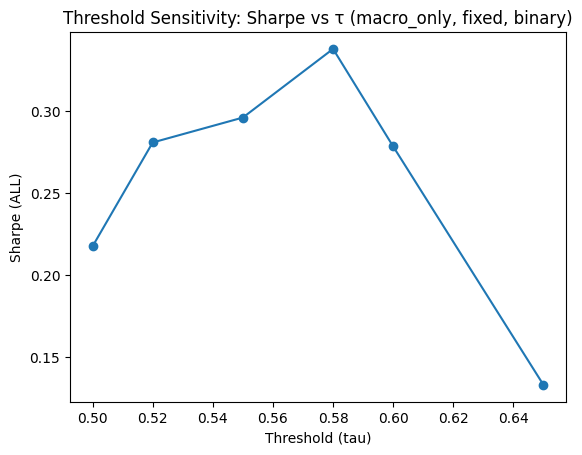

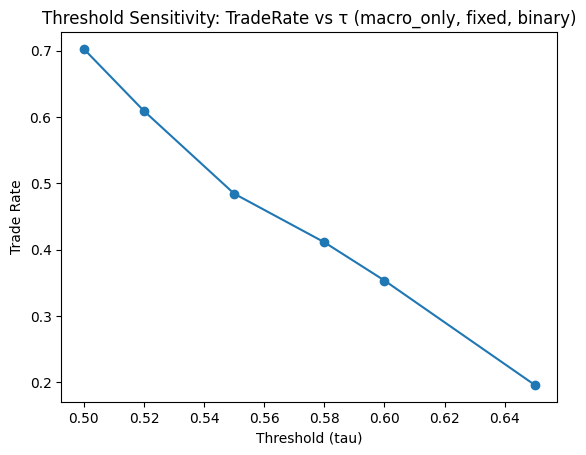

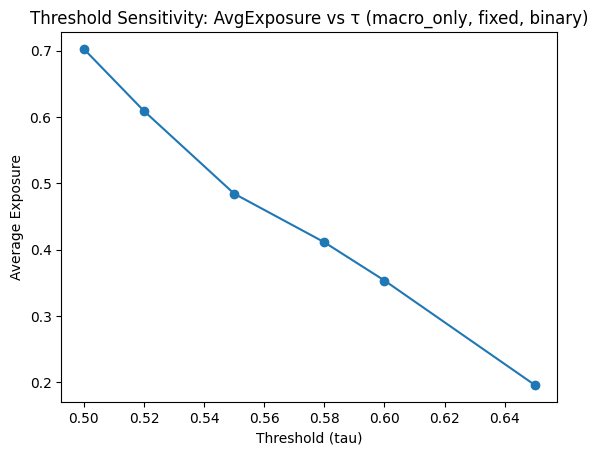

,name,tau,ALL_Sharpe,TradeRate,AvgExposure,ALL_AnnRet,ALL_AnnVol,ALL_MaxDD
1,macro_only_binary_tau_0.50,0.50,0.217508,0.702492,0.702492,0.031563,0.145113,-0.780421
3,macro_only_binary_tau_0.52,0.52,0.280847,0.609034,0.609034,0.036931,0.131500,-0.661190
5,macro_only_binary_tau_0.55,0.55,0.296057,0.484424,0.484424,0.034316,0.115909,-0.678584
7,macro_only_binary_tau_0.58,0.58,0.337928,0.411215,0.411215,0.036959,0.109370,-0.681687
9,macro_only_binary_tau_0.60,0.60,0.278419,0.353583,0.353583,0.028094,0.100904,-0.660591
11,macro_only_binary_tau_0.65,0.65,0.132945,0.196262,0.196262,0.011032,0.082979,-0.599873


In [41]:
# === Threshold Sensitivity (Single Config) ===
# Generates Sharpe vs tau and TradeRate vs tau for ONE chosen model family
# (e.g., macro_only + fixed + binary), so the plot is not mixed with fixed-vs-rolling.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- USER SETTINGS ----
FEATURE_SPEC = "macro_only"   # "macro_only", "diag_only", or "both"
SCHEME = "fixed"              # "fixed" or "roll"
GATE_TYPE = "binary"          # "binary" or "soft"
TAUS = [0.50, 0.52, 0.55, 0.58, 0.60, 0.65]

# ---- Build name prefix that matches your metrics_table["name"] ----
if SCHEME == "fixed":
    prefix = f"{FEATURE_SPEC}_{GATE_TYPE}_tau_"
else:
    prefix = f"{FEATURE_SPEC}_roll_{GATE_TYPE}_tau_"

# ---- Filter rows for this one configuration ----
df = metrics_table[metrics_table["name"].str.startswith(prefix)].copy()
df = df.dropna(subset=["tau"]).sort_values("tau")

# Sanity check
expected = [f"{prefix}{t:.2f}" for t in TAUS]
missing = [k for k in expected if k not in set(df["name"])]
if missing:
    print("WARNING: Missing some tau variants for this config:")
    for m in missing:
        print("  ", m)

# ---- Plot 1: Sharpe vs tau ----
plt.figure()
plt.plot(df["tau"], df["ALL_Sharpe"], marker="o")
plt.xlabel("Threshold (tau)")
plt.ylabel("Sharpe (ALL)")
plt.title(f"Threshold Sensitivity: Sharpe vs τ ({FEATURE_SPEC}, {SCHEME}, {GATE_TYPE})")
plt.show()

# ---- Plot 2: TradeRate vs tau ----
plt.figure()
plt.plot(df["tau"], df["TradeRate"], marker="o")
plt.xlabel("Threshold (tau)")
plt.ylabel("Trade Rate")
plt.title(f"Threshold Sensitivity: TradeRate vs τ ({FEATURE_SPEC}, {SCHEME}, {GATE_TYPE})")
plt.show()

# ---- Optional: AvgExposure vs tau (useful for interpretation) ----
plt.figure()
plt.plot(df["tau"], df["AvgExposure"], marker="o")
plt.xlabel("Threshold (tau)")
plt.ylabel("Average Exposure")
plt.title(f"Threshold Sensitivity: AvgExposure vs τ ({FEATURE_SPEC}, {SCHEME}, {GATE_TYPE})")
plt.show()

# ---- Optional: print the small table used for plotting ----
display(df[["name", "tau", "ALL_Sharpe", "TradeRate", "AvgExposure", "ALL_AnnRet", "ALL_AnnVol", "ALL_MaxDD"]])

#### **Feature Choice | Macro vs Diagnostics vs Both**

In [42]:
print([k for k in variants_store.keys() if "0.58" in k])

['macro_only_binary_tau_0.58', 'macro_only_soft_tau_0.58', 'diag_only_binary_tau_0.58', 'diag_only_soft_tau_0.58', 'both_binary_tau_0.58', 'both_soft_tau_0.58', 'macro_only_roll_binary_tau_0.58', 'macro_only_roll_soft_tau_0.58', 'diag_only_roll_binary_tau_0.58', 'diag_only_roll_soft_tau_0.58', 'both_roll_binary_tau_0.58', 'both_roll_soft_tau_0.58']


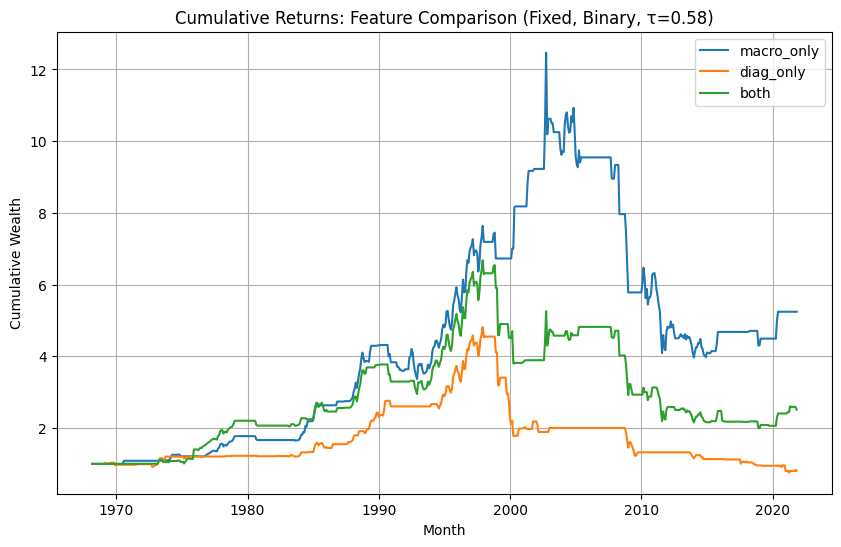

In [43]:
# --- Select comparable variants (fixed, binary, tau = 0.58) ---
selected_keys = [
    "macro_only_binary_tau_0.58",
    "diag_only_binary_tau_0.58",
    "both_binary_tau_0.58"
]

plt.figure(figsize=(10,6))

for key in selected_keys:
    df = variants_store[key]
    wealth = (1 + df["R_gated"]).cumprod()
    plt.plot(df["month"], wealth, label=key.replace("_binary_tau_0.58",""))

plt.title("Cumulative Returns: Feature Comparison (Fixed, Binary, τ=0.58)")
plt.xlabel("Month")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# --- Select comparable variants ---
selected_keys = [
    "macro_only_binary_tau_0.58",
    "diag_only_binary_tau_0.58",
    "both_binary_tau_0.58"
]

# --- Extract Sharpe only ---
table = metrics_table[
    metrics_table["name"].isin(selected_keys)
].copy()

# Clean labels
table["Feature_Set"] = table["name"].str.replace("_binary_tau_0.58", "", regex=False)

# Keep only Sharpe
table = table[["Feature_Set", "ALL_Sharpe"]].sort_values("ALL_Sharpe", ascending=False)

table.reset_index(drop=True)

,Feature_Set,ALL_Sharpe
0,macro_only,0.337928
1,both,0.206800
2,diag_only,0.013046


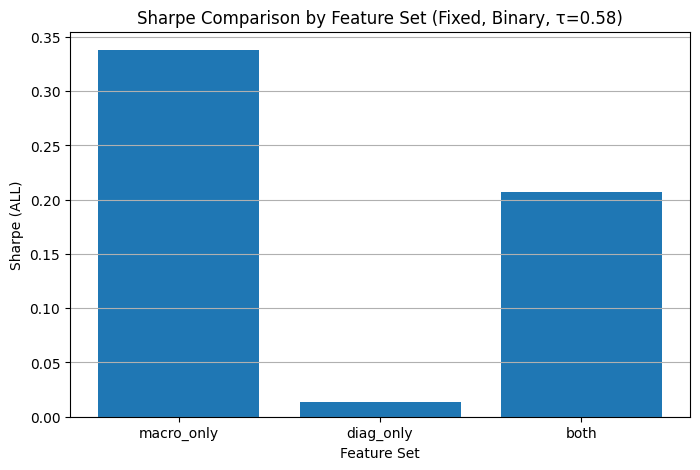

In [45]:
# --- Extract Sharpe values ---
subset = metrics_table[
    metrics_table["name"].isin(selected_keys)
].copy()

# Clean labels
subset["label"] = subset["name"].str.replace("_binary_tau_0.58", "", regex=False)

plt.figure(figsize=(8,5))
plt.bar(subset["label"], subset["ALL_Sharpe"])

plt.title("Sharpe Comparison by Feature Set (Fixed, Binary, τ=0.58)")
plt.ylabel("Sharpe (ALL)")
plt.xlabel("Feature Set")
plt.grid(axis="y")

plt.show()

## **P) Pick Best Gated Variant + Plots (Cumulative, Threshold Curves, Bull/Bear)**

We compare baseline and gated strategies using cumulative returns, threshold sensitivity, and regime-specific performance. These visualizations make it clear whether the gating mechanism improves risk-adjusted returns.

Best variant: macro_only_binary_tau_0.58 | tau: 0.58


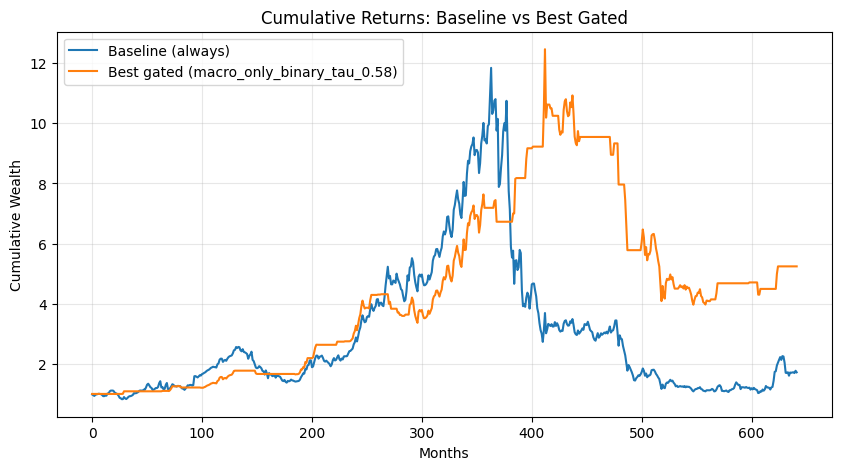

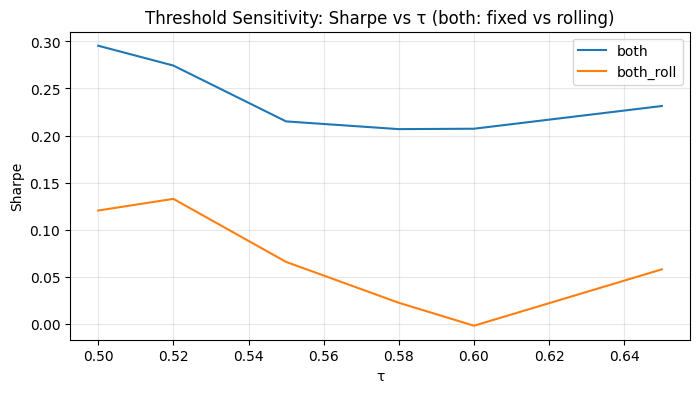

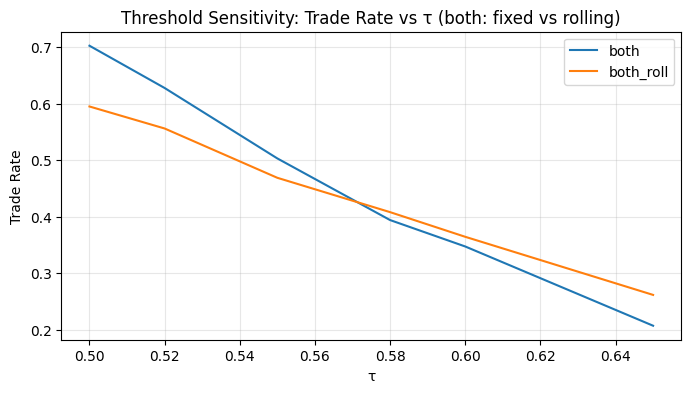

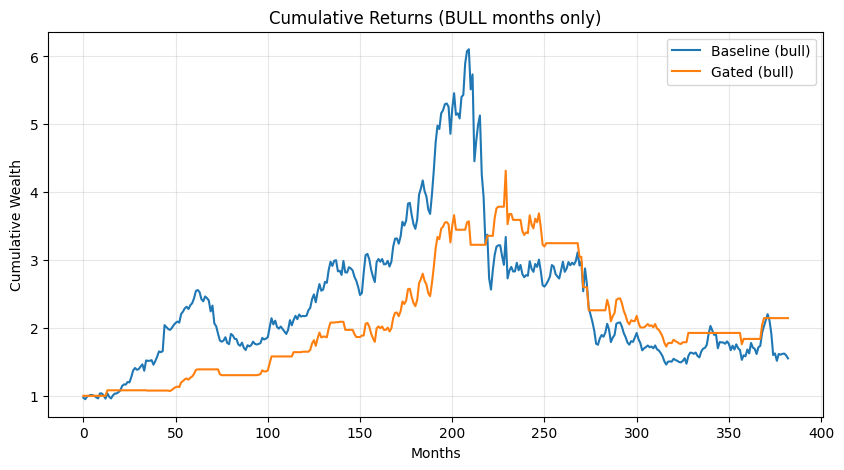

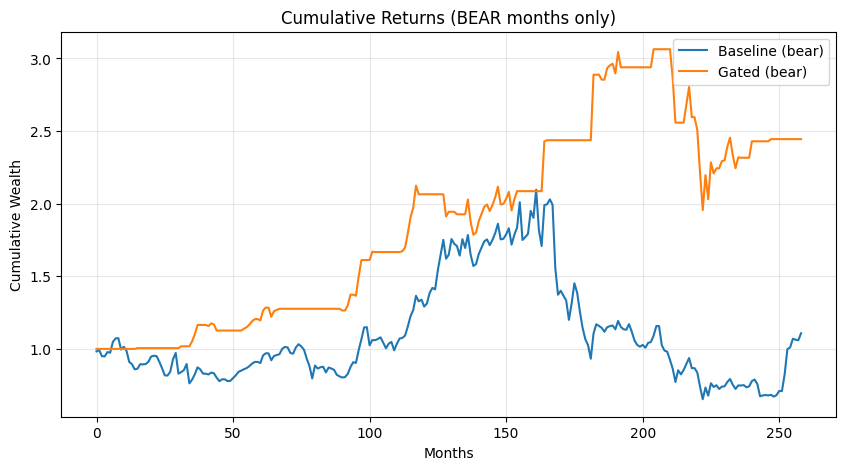

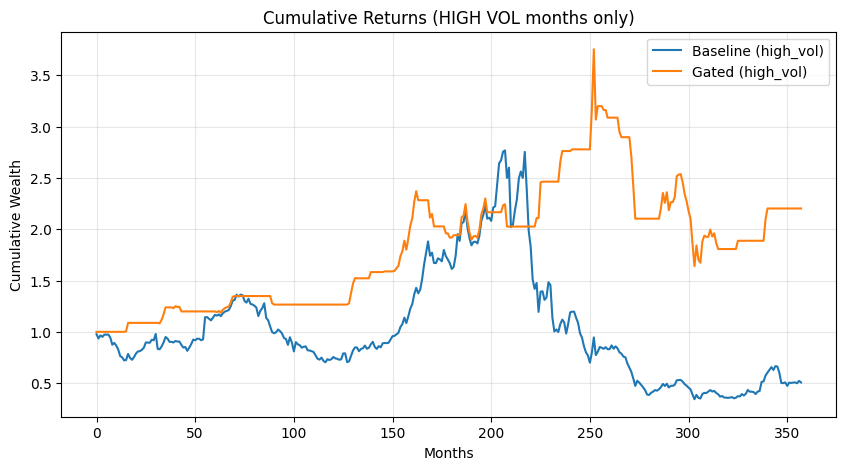

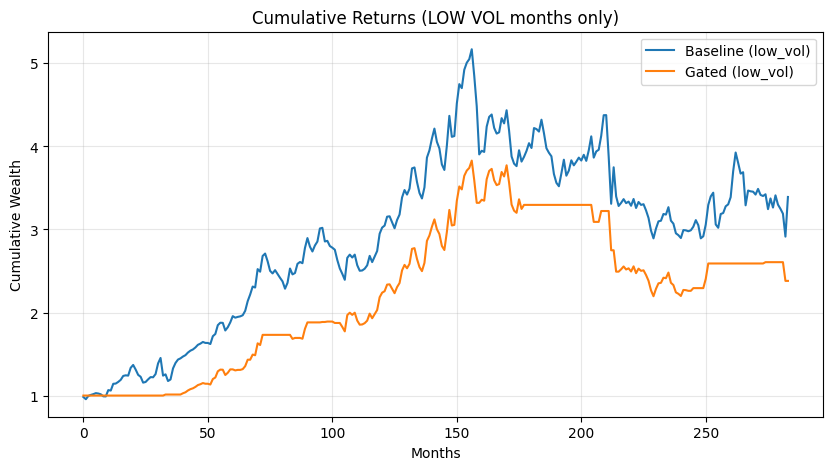

Mean p_t bull: 0.5602363021949316
Mean p_t bear: 0.5469660152983732
Trade rate bull: 0.4412532637075718
Trade rate bear: 0.3667953667953668


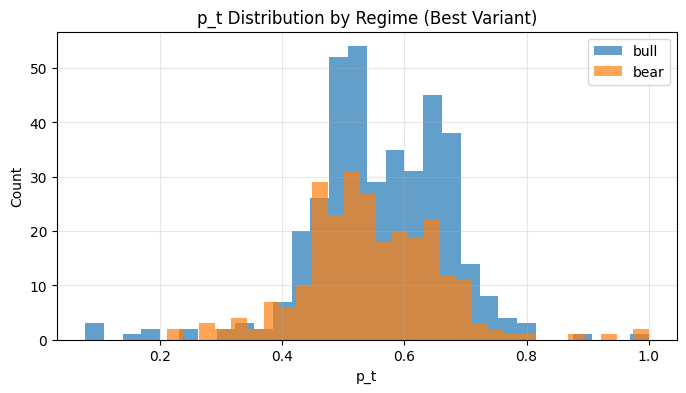

In [46]:
# ## **P) Pick Best Gated Variant + Plots (Cumulative, Threshold Curves, Bull/Bear, Vol Regime)**

# Helper: cumulative wealth plot
def plot_cum(series, label, ax):
    s = pd.Series(series).dropna()
    wealth = (1 + s).cumprod()
    ax.plot(wealth.values, label=label)

# --- 1) Pick best gated variant (exclude baseline where tau is NaN) ---
best_row = (
    metrics_table.dropna(subset=["tau"])
    .sort_values("ALL_Sharpe", ascending=False)
    .iloc[0]
)

best_name = best_row["name"]
best_tau  = float(best_row["tau"])
print("Best variant:", best_name, "| tau:", best_tau)

best_df = variants_store[best_name].copy()

# --- 2) Overall cumulative: baseline vs best ---
fig, ax = plt.subplots(figsize=(10, 5))
plot_cum(baseline["R_gated"], "Baseline (always)", ax)
plot_cum(best_df["R_gated"], f"Best gated ({best_name})", ax)
ax.set_title("Cumulative Returns: Baseline vs Best Gated")
ax.set_xlabel("Months")
ax.set_ylabel("Cumulative Wealth")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# --- 3) Threshold sensitivity (fixed vs rolling, both + binary) ---
# Change these prefixes if you want a different comparison set
prefixes = ["both_binary_tau_", "both_roll_binary_tau_"]

# Sharpe vs tau
plt.figure(figsize=(8, 4))
for pref in prefixes:
    tmp = metrics_table[metrics_table["name"].str.startswith(pref)].copy()
    if len(tmp) == 0:
        continue
    tmp["tau"] = tmp["tau"].astype(float)
    tmp = tmp.sort_values("tau")
    lbl = pref.replace("_binary_tau_", "")  # "both" vs "both_roll"
    plt.plot(tmp["tau"].values, tmp["ALL_Sharpe"].values, label=lbl)

plt.title("Threshold Sensitivity: Sharpe vs τ (both: fixed vs rolling)")
plt.xlabel("τ")
plt.ylabel("Sharpe")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Trade rate vs tau
plt.figure(figsize=(8, 4))
for pref in prefixes:
    tmp = metrics_table[metrics_table["name"].str.startswith(pref)].copy()
    if len(tmp) == 0:
        continue
    tmp["tau"] = tmp["tau"].astype(float)
    tmp = tmp.sort_values("tau")
    lbl = pref.replace("_binary_tau_", "")
    plt.plot(tmp["tau"].values, tmp["TradeRate"].values, label=lbl)

plt.title("Threshold Sensitivity: Trade Rate vs τ (both: fixed vs rolling)")
plt.xlabel("τ")
plt.ylabel("Trade Rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 4) Bull-only & Bear-only cumulative plots ---
for reg in ["bull", "bear"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_cum(baseline.loc[baseline["regime"] == reg, "R_gated"], f"Baseline ({reg})", ax)
    plot_cum(best_df.loc[best_df["regime"] == reg, "R_gated"], f"Gated ({reg})", ax)
    ax.set_title(f"Cumulative Returns ({reg.upper()} months only)")
    ax.set_xlabel("Months")
    ax.set_ylabel("Cumulative Wealth")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

# --- 5) High-vol vs low-vol cumulative plots (if vol_regime exists) ---
if "vol_regime" in baseline.columns and "vol_regime" in best_df.columns:
    for reg in ["high_vol", "low_vol"]:
        fig, ax = plt.subplots(figsize=(10, 5))
        plot_cum(baseline.loc[baseline["vol_regime"] == reg, "R_gated"], f"Baseline ({reg})", ax)
        plot_cum(best_df.loc[best_df["vol_regime"] == reg, "R_gated"], f"Gated ({reg})", ax)
        ax.set_title(f"Cumulative Returns ({reg.replace('_',' ').upper()} months only)")
        ax.set_xlabel("Months")
        ax.set_ylabel("Cumulative Wealth")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

# --- 6) Gate behavior by regime (mean p_t + exposure rates) ---
bull_p = best_df.loc[best_df["regime"] == "bull", "p_t"].dropna()
bear_p = best_df.loc[best_df["regime"] == "bear", "p_t"].dropna()

print("Mean p_t bull:", float(bull_p.mean()) if len(bull_p) else np.nan)
print("Mean p_t bear:", float(bear_p.mean()) if len(bear_p) else np.nan)
print("Trade rate bull:", float((best_df.loc[best_df["regime"] == "bull", "exposure"] > 0).mean()))
print("Trade rate bear:", float((best_df.loc[best_df["regime"] == "bear", "exposure"] > 0).mean()))

plt.figure(figsize=(8, 4))
bull_p.hist(alpha=0.7, bins=30, label="bull")
bear_p.hist(alpha=0.7, bins=30, label="bear")
plt.title("p_t Distribution by Regime (Best Variant)")
plt.xlabel("p_t")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [47]:
best_row = metrics_table.dropna(subset=["tau"])\
    .sort_values("ALL_Sharpe", ascending=False)\
    .iloc[0]
print(best_name, best_tau)

macro_only_binary_tau_0.58 0.58


##### **Why the Meta-Model Struggles to Learn Regime Signals**

The results indicate that the meta-model is not a strong regime detector, as evidenced by the substantial overlap in gate probability distributions across bull and bear periods. This behavior can be attributed to several factors.

First, the target variable used for training the meta-model is inherently noisy. The label is defined as whether the next month’s long-short return is positive, which is highly volatile and influenced by short-term randomness. As a result, the model is trained on a weak and inconsistent signal.

Second, the feature set does not directly encode regime information. While macro variables and diagnostic statistics provide useful context, they are indirect proxies and do not clearly separate different market states. This leads the model to learn only small statistical differences rather than distinct regime boundaries.

Third, the use of a simple logistic regression model limits the ability to capture nonlinear and time-dependent relationships that are characteristic of financial regimes. Combined with the noisy labels, this results in predicted probabilities that are clustered around 0.5 and exhibit significant overlap across regimes.

Overall, the meta-model does not reliably classify regimes but instead produces weak directional signals. Despite this, the gating mechanism remains effective because even small shifts in predicted probabilities, when combined with thresholding, are sufficient to reduce exposure during unfavorable conditions and improve overall risk-adjusted performance.

## **Q) Export Artifacts**
Final datasets and results are saved for reporting and reproducibility. This ensures that all outputs can be reused for analysis, presentation, or further experimentation.

In [48]:
# ## **Q) Export Artifacts**

# results_df.to_csv("results_df_stock_level.csv", index=False)
# strategy_df.to_csv("strategy_baseline_monthly.csv", index=False)
# meta.to_csv("meta_dataset.csv", index=False)
# metrics_table.to_csv("metrics_table_all_variants.csv", index=False)

print("Artifacts ready:")
print("results_df:", results_df.shape)
print("strategy_df:", strategy_df.shape)
print("meta:", meta.shape)
print("metrics_table:", metrics_table.shape)
print("Best variant:", best_name)

Artifacts ready:
results_df: (2899870, 5)
strategy_df: (644, 4)
meta: (642, 22)
metrics_table: (73, 16)
Best variant: macro_only_binary_tau_0.58


## **FINAL SANITY CHECK CELL**

In [49]:
print("\n================ CHECKPOINT 1: LABEL ALIGNMENT ================\n")

tmp = df_model[[ID_COL, MONTH_COL, RET_COL, "y_next"]].copy()
tmp = tmp.sort_values([ID_COL, MONTH_COL])

# pick one stock with enough history
one = tmp[ID_COL].value_counts().index[0]
s = tmp[tmp[ID_COL] == one].head(6)

print(s)

diff = s["y_next"].iloc[:-1].values - s[RET_COL].iloc[1:].values
print("\nDifference between y_next and next ret_excess (should be ~0):")
print(diff)


print("\n================ CHECKPOINT 3: RESULTS SANITY ================\n")

print("Results shape:", results_df.shape)

print("\nMissing values:")
print("pred NA %:", results_df["pred"].isna().mean())
print("ret_next NA %:", results_df["ret_next"].isna().mean())

print("\nMonth range:")
print("Min month:", results_df[MONTH_COL].min())
print("Max month:", results_df[MONTH_COL].max())

print("\nSample predictions:")
print(results_df[[ID_COL, MONTH_COL, "pred", "ret_next"]].head())


print("\n================ EXTRA CHECK: DISTRIBUTIONS ================\n")

print("Predictions summary:")
print(results_df["pred"].describe())

print("\nReturns summary:")
print(results_df["ret_next"].describe())


print("\n================ FINAL VERDICT ================\n")

if (
    results_df["pred"].isna().sum() == 0 and
    results_df["ret_next"].isna().sum() == 0 and
    (abs(diff).max() < 1e-6)
):
    print("✅ All major checks PASSED — pipeline is consistent and leakage-safe")
else:
    print("⚠️ Something looks off — inspect outputs above")


================ CHECKPOINT 1: LABEL ALIGNMENT ================

      permno      month  ret_excess    y_next
449    24440 1957-01-31    0.054895  0.003811
939    24440 1957-02-28    0.003811  0.047083
1429   24440 1957-03-31    0.047083  0.026050
1920   24440 1957-04-30    0.026050  0.003180
2411   24440 1957-05-31    0.003180 -0.013894
2902   24440 1957-06-30   -0.013894 -0.033942

Difference between y_next and next ret_excess (should be ~0):
[0. 0. 0. 0. 0.]

================ CHECKPOINT 3: RESULTS SANITY ================

Results shape: (2899870, 5)

Missing values:
pred NA %: 0.0
ret_next NA %: 0.0

Month range:
Min month: 1968-01-31 00:00:00
Max month: 2021-11-30 00:00:00

Sample predictions:
   permno      month      pred  ret_next
0   10006 1968-01-31  0.019908 -0.041053
1   10014 1968-01-31  0.032069 -0.084360
2   10030 1968-01-31  0.008427  0.000302
3   10057 1968-01-31  0.009524 -0.049614
4   10102 1968-01-31  0.011924 -0.052809

================ EXTRA CHECK: DISTRIBUTIONS 

## **Conclusion**

This project evaluates whether a simple gating mechanism can improve the risk-adjusted performance of a return prediction strategy. While gating does not consistently enhance returns across all market conditions, it proves effective as a risk management tool by reducing exposure during unfavorable periods—particularly in bear and high-volatility environments—thereby improving overall Sharpe.

Our results show that a fixed logistic meta-model using macro features outperforms more adaptive rolling alternatives, not because markets are stable, but because the underlying signals are weak and noisy. Frequent refitting amplifies estimation noise and leads to unstable decisions, whereas a fixed model provides more consistent behavior.

Importantly, the success of gating does not rely on accurately identifying market regimes. Instead, it leverages imperfect and weak directional signals through simple threshold-based rules to avoid the most adverse periods while maintaining sufficient market participation.

Overall, the findings highlight a key trade-off in regime-aware modeling: increasing adaptability and complexity does not necessarily improve performance, especially in low signal-to-noise settings. Future work could explore more robust approaches to balancing stability and adaptability, as well as improving signal quality for more reliable regime discrimination.